# Objectif 

Notebook pour la prise en main des données 

Date de création : 02/07/2026

In [1]:
# this will download 1 hour of data from a FR network station, and display a wafeform plot.
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.io.wavfile as wavfile
import scipy.signal as sp
import matplotlib.pyplot as plt

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import pandas as pd

from stage_VictorM2.src.utils import *
from stage_VictorM2.src.utils_wav import process_and_plot, plot_spectrogram

In [2]:
# params = {}
# params["backend"] = "QtAgg"
# plt.rcParams.update(params)

%matplotlib inline

## Définition des variables utiles 

In [3]:
root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\stage_VictorM2"
root_data = os.path.join(root, "data")
root_wav = os.path.join(root_data, "wav")

root_img = os.path.join(root, "img")
root_raw_img = os.path.join(root_img, "raw")

folders = [root_data, root_wav, root_img, root_raw_img]
for fold in folders:
    if not os.path.exists(fold):
        os.makedirs(fold)

# Chargement des données 

## Métadonnées réseau 9R 

In [4]:
fpath = os.path.join(root_data, "stations_9R.csv")
ds_9R = pd.read_csv(fpath)

In [5]:
ds_9R

,client,network,station,restricted_status,latitude,longitude,elevation,channels,start_date,end_date,duration,height_above_mean_sea_level,elevation_diff
0,IRIS,9R,OBS01,open,18.51055,-81.76852,-5114.0,EDH_EL1_EL2_ELZ,2022-12-05,2023-06-23 23:59:59.999900,1.736640e+07,-5102,-12.0
1,IRIS,9R,OBS02,open,18.51072,-81.74122,-4533.0,EDH_EL1_EL2_ELZ,2022-12-06,2023-06-23 23:59:59.999900,1.728000e+07,-4587,54.0
2,IRIS,9R,OBS03,open,18.48431,-81.76879,-5139.0,EDH_EL1_EL2_ELZ,2022-12-06,2023-06-23 23:59:59.999900,1.728000e+07,-5120,-19.0
3,IRIS,9R,OBS05,open,18.45662,-81.76946,-4995.0,EDH_EL1_EL2_ELZ,2022-12-06,2023-06-24 23:59:59.999900,1.736640e+07,-4928,-67.0
4,IRIS,9R,OBS06,open,18.45857,-81.74100,-4824.0,EDH_EL1_EL2_ELZ,2022-12-06,2023-06-24 23:59:59.999900,1.736640e+07,-4782,-42.0
5,IRIS,9R,OBS07,open,18.45582,-81.71142,-5075.0,EDH_EL1_EL2_ELZ,2022-12-06,2023-06-24 23:59:59.999900,1.736640e+07,-5134,59.0
6,IRIS,9R,OBS08,open,18.42997,-81.76982,-4367.0,EDH_EL1_EL2_ELZ,2022-12-06,2023-06-24 23:59:59.999900,1.736640e+07,-4337,-30.0
7,IRIS,9R,OBS09,open,18.42769,-81.74040,-4739.0,EDH_EL1_EL2_ELZ,2022-12-06,2023-06-24 23:59:59.999900,1.736640e+07,-4565,-174.0
8,IRIS,9R,OBS10,open,18.42986,-81.71073,-5087.0,EDH_EL1_EL2_ELZ,2022-12-06,2023-06-24 23:59:59.999900,1.736640e+07,-5081,-6.0
9,IRIS,9R,OBS11,open,18.40188,-81.79697,-2776.0,EDH_EL1_EL2_ELZ,2022-12-07,2023-06-25 23:59:59.999900,1.736640e+07,-2752,-24.0


## Données de position des capteurs 

Les données du CSV précèdent sont stockées également dans un netcdf dédié pour simplifier la manipulation

In [6]:
fpath = os.path.join(root_data, "9R_network.nc")
ds_network_9R = xr.load_dataset(fpath)

In [7]:
ds_network_9R

<xarray.Dataset> Size: 1kB
Dimensions:      (receiver_id: 35)
Coordinates:
  * receiver_id  (receiver_id) int64 280B 1 2 3 5 6 7 8 ... 31 33 34 35 37 38 39
Data variables:
    latitude     (receiver_id) float64 280B 18.51 18.51 18.48 ... 18.27 18.24
    longitude    (receiver_id) float64 280B -81.77 -81.74 ... -81.74 -81.77
    elevation    (receiver_id) float64 280B -5.114e+03 -4.533e+03 ... -4.908e+03

## Données de bathy 

Données extraites du modèle GEBCO 2021 (on pourra remplacer par GEBCO 2026). Les données sont au format netcdf, on pourra extraire une zone plus large si besoin (GEBCO est un modèle global).

Code d'extraction : voir fichier 9R_preprocess.py

In [8]:
ds_bathy = xr.open_dataset(os.path.join(root_data, "bathy.nc"))

In [9]:
ds_bathy

<xarray.Dataset> Size: 12MB
Dimensions:    (lat: 2400, lon: 2400)
Coordinates:
  * lat        (lat) float64 19kB 13.38 13.39 13.39 13.39 ... 23.37 23.37 23.38
  * lon        (lon) float64 19kB -86.75 -86.74 -86.74 ... -76.76 -76.76 -76.75
Data variables:
    elevation  (lat, lon) int16 12MB ...
Attributes:
    description:     Bathymetry data from GEBCO 2021
    geodesic_frame:  WGS84

## Données de AIS 

Données AIS pour la zone et pour le mois de janvier, il faut qu'on récupère le reste rapidement.

Les données d'origines sont dans le fichier .parquet et ont été extraites (et ré-interpolées) avec le code extract_subset_ais()

Code extraction : voir fichier 9R_preprocess.py

In [10]:
ds_ais = xr.open_dataset(os.path.join(root_data, "ais.nc"))

In [11]:
ds_ais

<xarray.Dataset> Size: 4GB
Dimensions:  (mmsi: 1822, time: 267832)
Coordinates:
  * mmsi     (mmsi) uint32 7kB 403536000 403520001 ... 378399000 626079000
  * time     (time) datetime64[ns] 2MB 2022-12-31T23:59:10 ... 2023-01-31T23:...
Data variables:
    lon      (mmsi, time) float32 2GB ...
    lat      (mmsi, time) float32 2GB ...
Attributes:
    network:                  9R
    description:              AIS data for the 9R network area, interpolated ...
    interpolation_time_step:  10.0
    geodesic_frame:           WGS84

## Données OBS 

Un bout de code pour charger les données des OBS du réseau. Je te conseille de commencer par une petite période comme c'est le cas dans l'exemple ci-dessous. 

Dans le bout de code ci-dessous la logique est la suivante : 

* Chargement des données depuis le serveur avec l'API OBSPy
* Sauvegarde des données dans un fichier .wav dont la nomenclature donne nom du capteur + période 

Par la suite si tu le souhaites tu peux agréger toutes les données dans un dataset NETCDF pour simplifier la manipulation. Il y a la fonction prepocess_wav() dans le fichier 9R_preprocess.py pour faire ça. 

Quelques trucs à vérifier pour les données : 

* Corrections de la réponse des capteurs : voir ce qui est fait dans la fonction utilisée ci-dessous.
* Unité des figures de spectro en fonction du paramètre de la fonction stft (éventuellement passer sur la nouvelle implémentation scipy ?)


### Chargement d'une période d'intérêt

In [12]:
fmt = "%Y-%m-%d_%H-%M-%S"
start_time = pd.to_datetime("2023-05-03_22-00-00", format=fmt)
end_time = start_time + pd.Timedelta(minutes=10)

In [13]:
# 9R
print(f"Processing data from {start_time} to {end_time}...")
# ============================================================
# CONFIG
# ============================================================

data_info = {
    "client": "EARTHSCOPE",
    "network": "9R",
    "stations": [
        "OBS01",
        "OBS02",
        "OBS03",
        # # "OBS04",
        # "OBS05",
        # "OBS06",
        # "OBS07",
        # "OBS08",
        # "OBS09",
        # "OBS10",
        # "OBS11",
        # "OBS12",
        # "OBS13",
        # "OBS14",
        # "OBS15",
        # "OBS16",
        # "OBS17",
        # "OBS18",
        # "OBS19",
        # "OBS20",
        # "OBS21",
        # "OBS22",
        # "OBS23",
        # "OBS24",
        # "OBS25",
        # "OBS26",
        # # "OBS27",  # Corrompu
        # "OBS28",
        # "OBS29",
        # "OBS30",
        # "OBS31",
        # # "OBS32",  # Corrompu
        # "OBS33",
        # "OBS34",
        # "OBS35",
        # # "OBS36",  # Corrompu
        # "OBS37",
        # "OBS38",
        # "OBS39",
    ],
    "channel": "EDH",
    "start_time": start_time,
    "end_time": end_time,
}

# ============================================================
# RUN PIPELINE
# ============================================================

fig_folder = os.path.join(root_raw_img, f"{start_time.strftime('%Y-%m-%d')}")
if not os.path.exists(fig_folder):
    os.makedirs(fig_folder, exist_ok=True)


st, inv = process_and_plot(
    data_info,
    pre_filt=(0.05, 0.1, 100, 120),
    response_output="DEF",
    save_figures=True,
    save_path=fig_folder,
    plot_map=False,
    plot_sig=False,
    plot_spectro=True,
    plot_power_sprectral_density=False,
    show=False,
)

for net in inv:
    for sta in net:
        print(f"Station {sta.code}")
        print("  Latitude:", sta.latitude)
        print("  Longitude:", sta.longitude)
        print("  Elevation:", sta.elevation)
        print("  Start:", sta.start_date)
        print("  End:", sta.end_date)


# Build filename
fmt = "%Y-%m-%d_%H-%M-%S"
date_start = pd.to_datetime(start_time).strftime(fmt)
date_end = (pd.to_datetime(end_time)).strftime(fmt)
fname = f"signal_{data_info['network']}_{data_info['channel']}_{date_start}_{date_end}_"  # on sauvegarde les signaux corriges dans un fichier .wav

for tr in st:
    fpath = os.path.join(root_wav, fname+ f"{tr.stats.station}.wav")

    # Save corrected signal
    wavfile.write(
        fpath,
        int(tr.meta.sampling_rate),
        tr.data,
    )

Processing data from 2023-05-03 22:00:00 to 2023-05-03 22:10:00...
Loading data...
Processing traces...

--- 9R.OBS01..EDH ---
SPL: 126.2 dB re 1 µPa

--- 9R.OBS02..EDH ---
SPL: 124.6 dB re 1 µPa

--- 9R.OBS03..EDH ---
SPL: 126.4 dB re 1 µPa
Station OBS01
  Latitude: 18.51055
  Longitude: -81.76852
  Elevation: -5114.0
  Start: 2022-12-05T00:00:00.000000Z
  End: 2023-06-23T23:59:59.999900Z
Station OBS02
  Latitude: 18.51072
  Longitude: -81.74122
  Elevation: -4533.0
  Start: 2022-12-06T00:00:00.000000Z
  End: 2023-06-23T23:59:59.999900Z
Station OBS03
  Latitude: 18.48431
  Longitude: -81.76879
  Elevation: -5139.0
  Start: 2022-12-06T00:00:00.000000Z
  End: 2023-06-23T23:59:59.999900Z


# Illustration des données 

## Données AIS et bathy 

Quelques exemples d'illustration des données AIS et Bathy dans la zone, principalement pour reproduire les figures du sujet de stage. 

(<Figure size 1000x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Shaded Bathymetry'}>)

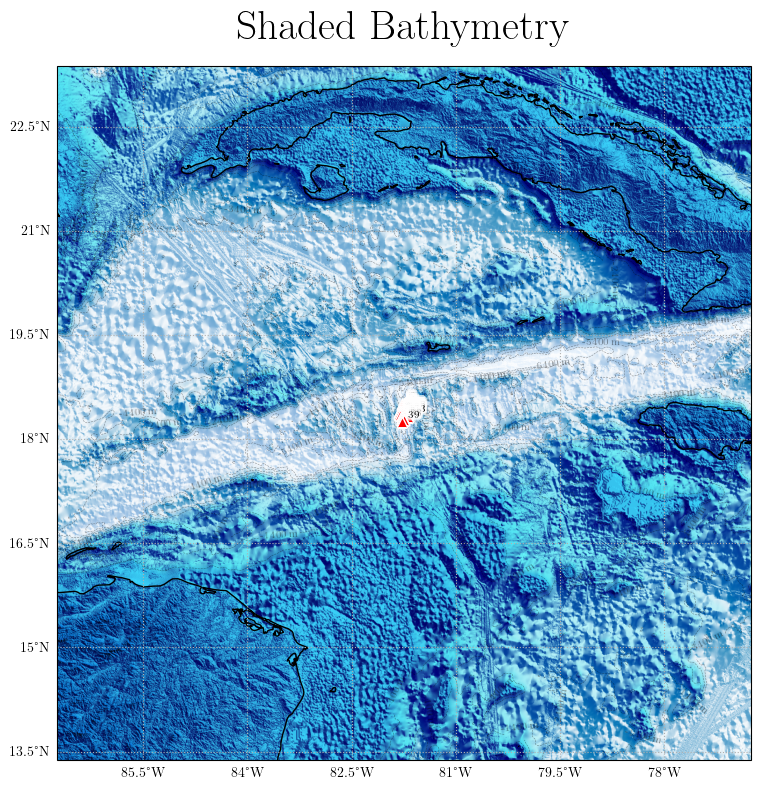

In [14]:
plot_network_and_bathy(ds_bathy, ds_network_9R)

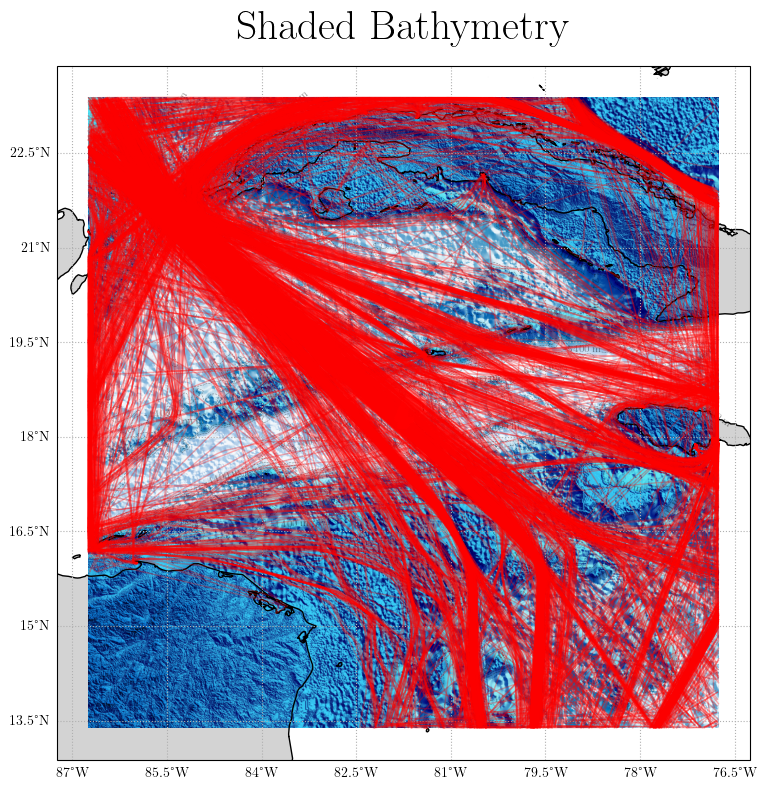

In [15]:
plot_ais_traj_over_bathy(ds_bathy, ds_network_9R, ds_ais)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


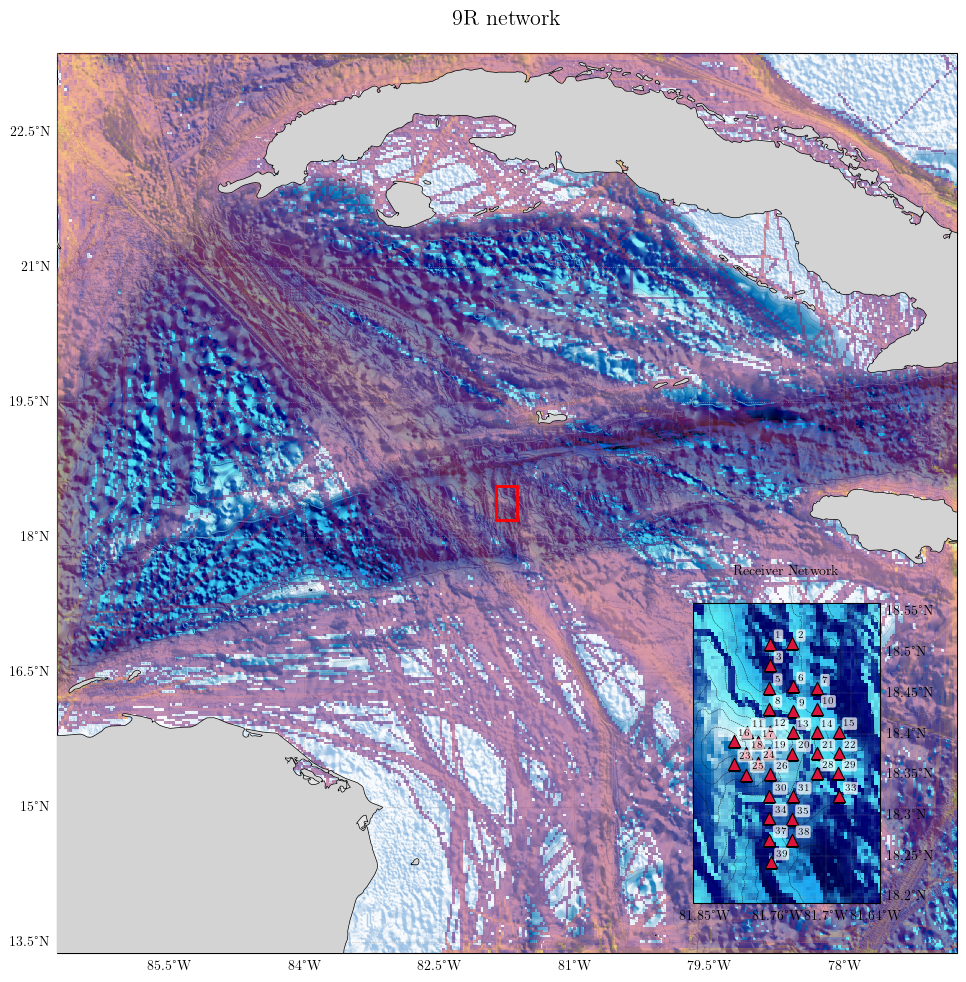

In [16]:
plot_ais_density_over_bathy(ds_bathy, ds_network_9R, ds_ais)

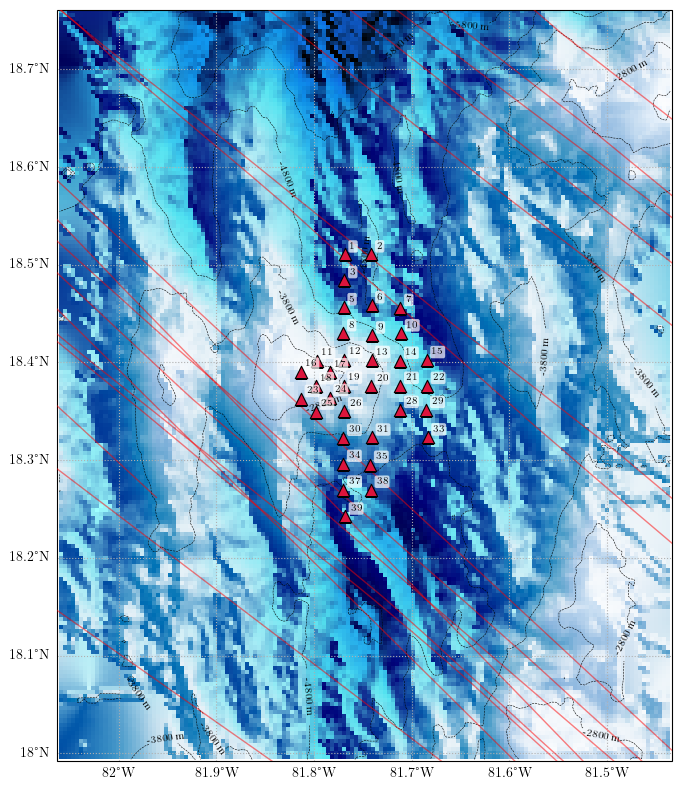

In [17]:
plot_ais_traj_and_bathy_zoom_network(ds_bathy, ds_network_9R, ds_ais, lon_lat_extent_deg=0.5)

## Données OBS 

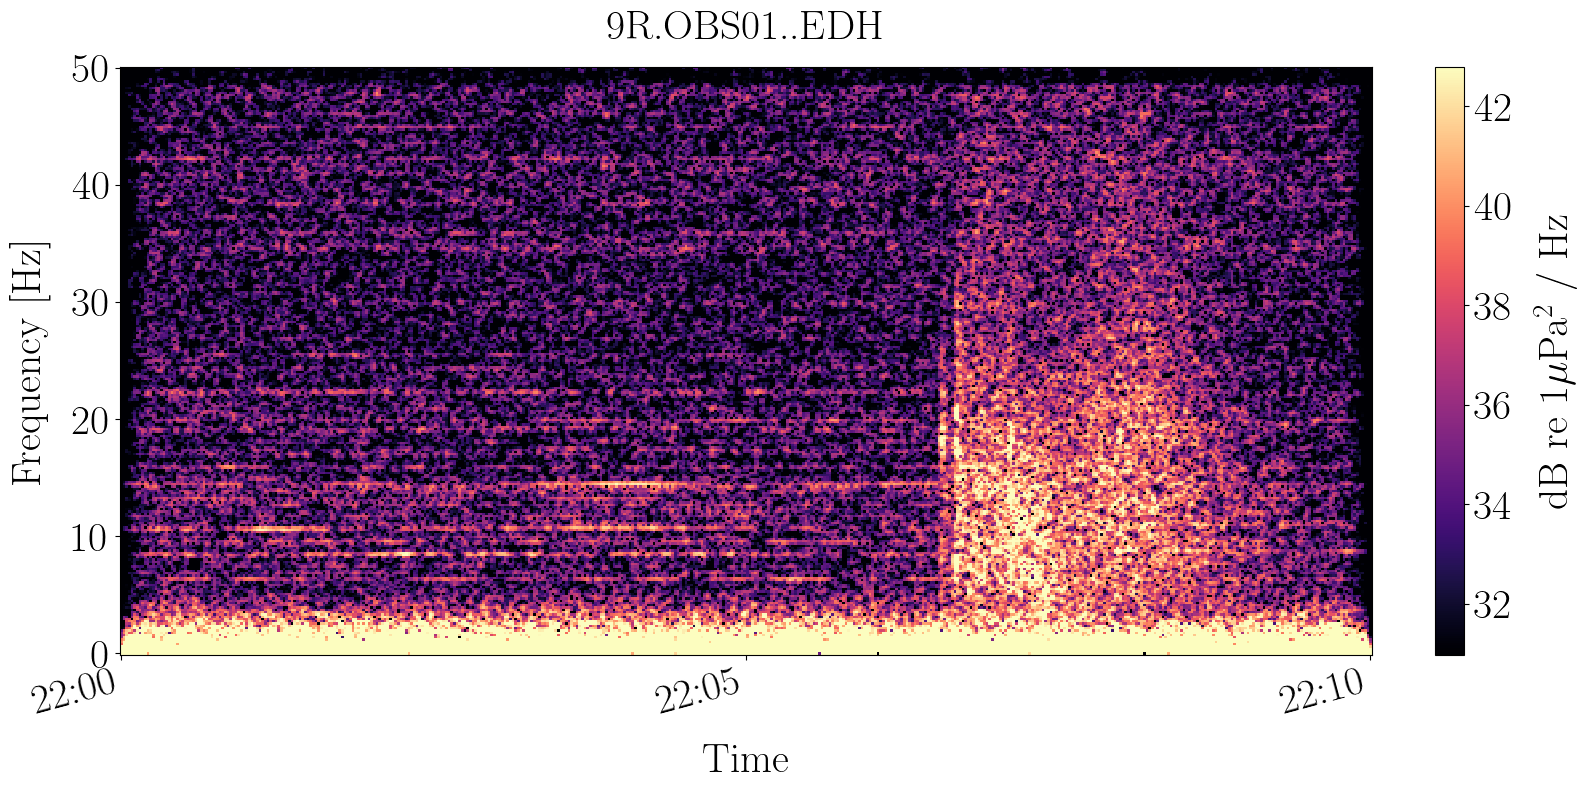

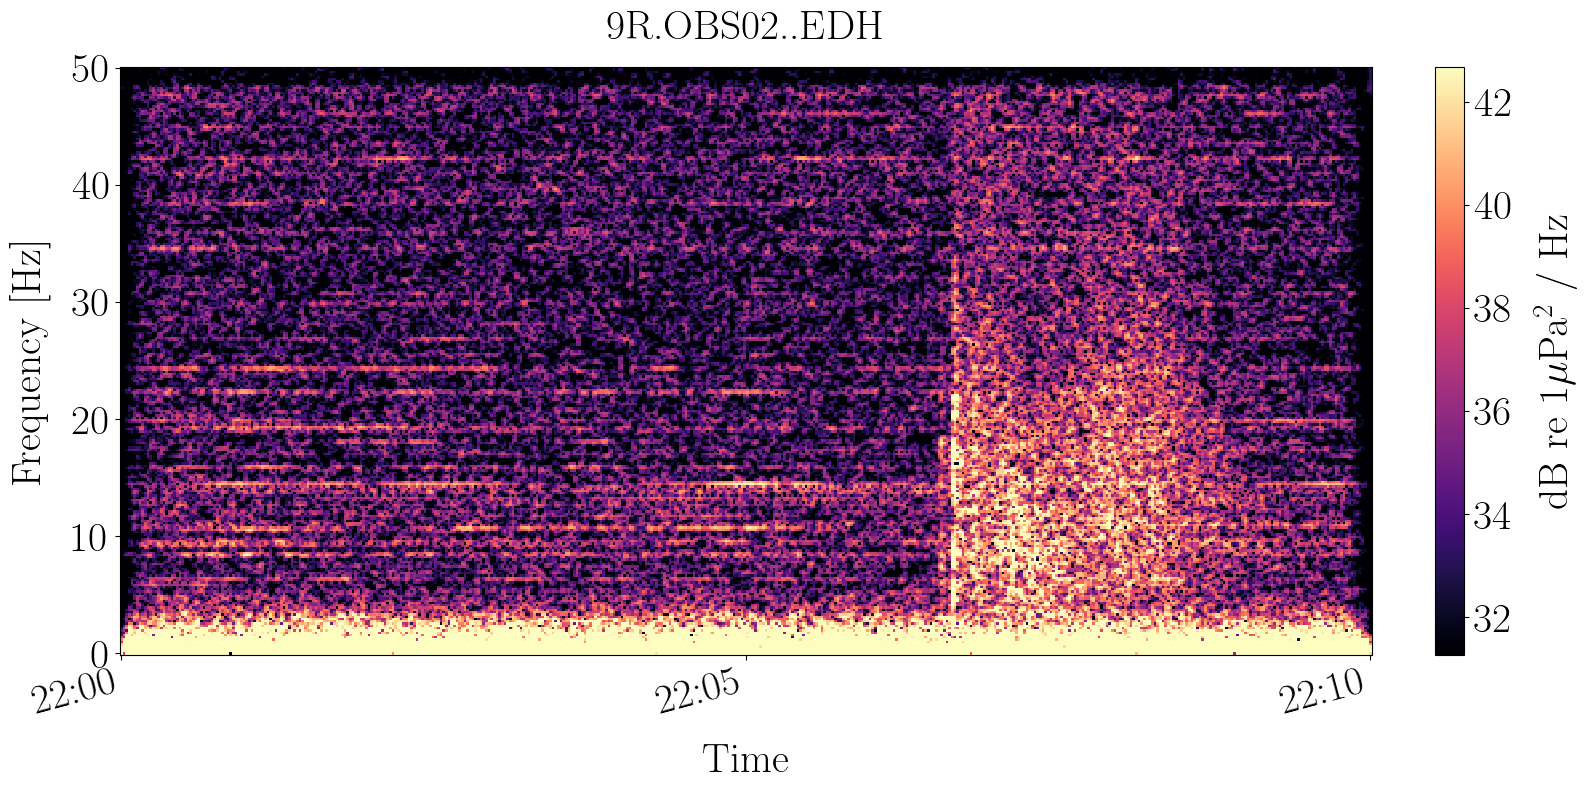

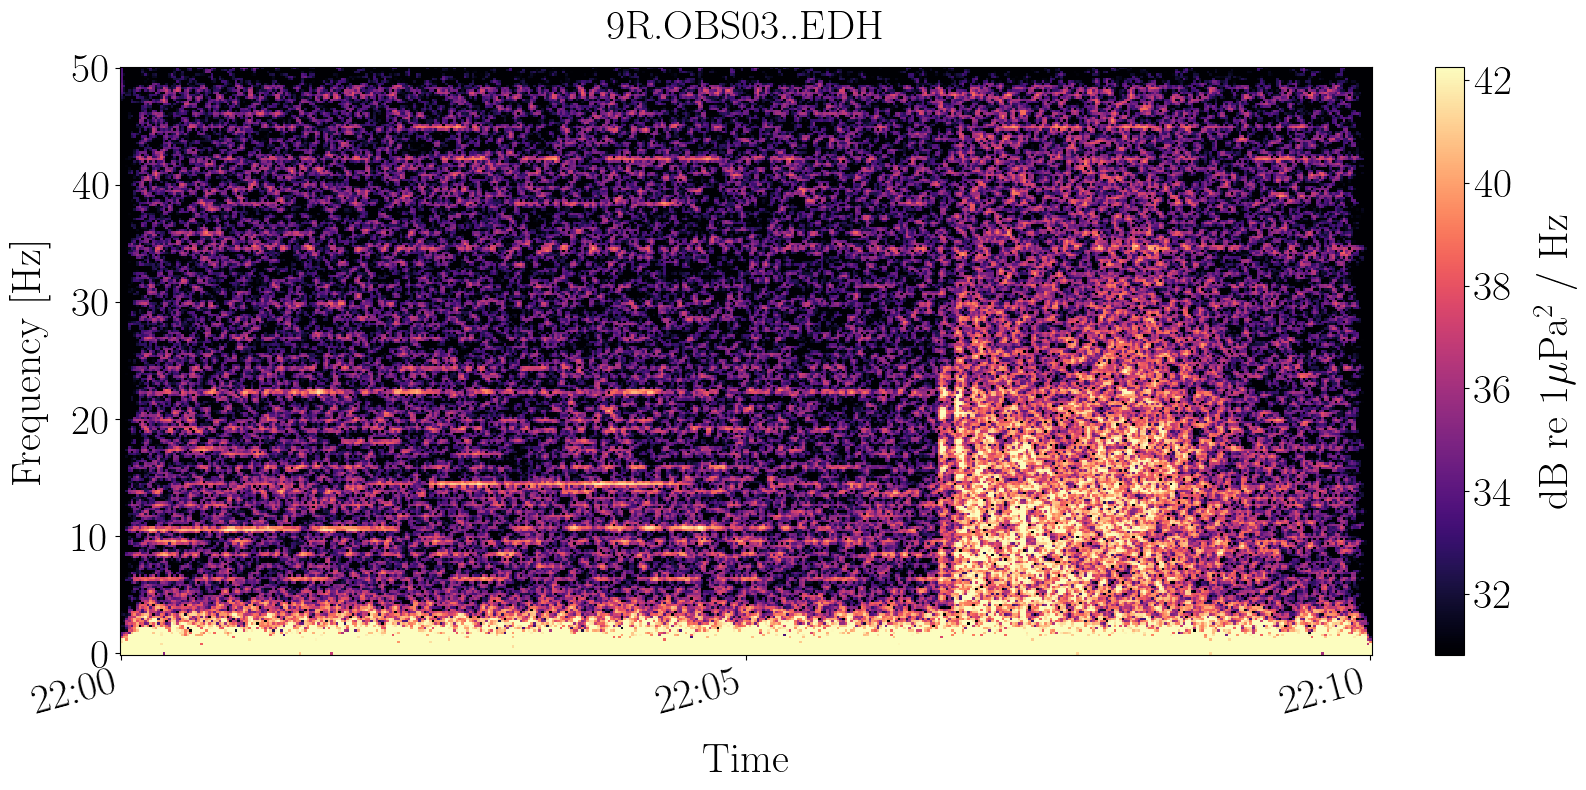

In [18]:
for tr in st:
    plot_spectrogram(tr, save=False, save_path=None, nperseg=512, overlap=0.75)